# Chronic Kidney Disease - Exploratory Data Analysis

## Chronic Kidney Disease (UCI, n=400)

This dataset has the heaviest missingness of the four (several lab columns
missing 20-38% of values) because it was assembled from real clinical records
with incomplete lab panels - not every patient received every test. The raw
target label also has a whitespace artifact (`"ckd\t"`), cleaned in
`src/preprocessing.py` before this notebook's `target` column is derived.


In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import get_disease
from src.preprocessing import DiseasePreprocessor
from src import eda

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)


In [2]:
disease = get_disease("ckd")
pre = DiseasePreprocessor(disease)
raw_df = pre.load_raw()
df = pre.clean_raw(raw_df)
print(f"Shape after cleaning: {df.shape}")
df.head()

2026-07-30 15:47:59,037 [INFO] [ckd] loaded raw data: 400 rows x 25 cols


Shape after cleaning: (400, 25)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,target
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no,1
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38.0,6000.0,NaN,no,no,no,good,no,no,1
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes,1
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,1
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35.0,7300.0,4.6,no,no,no,good,no,no,1


## 1. Summary Statistics

In [3]:
eda.summary_statistics(df)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max,missing,dtype
age,391.0,NaN,NaN,NaN,51.483376,17.169714,2.0,42.0,55.0,64.5,90.0,9,float64
bp,388.0,NaN,NaN,NaN,76.469072,13.683637,50.0,70.0,80.0,80.0,180.0,12,float64
sg,353.0,NaN,NaN,NaN,1.017408,0.005717,1.005,1.01,1.02,1.02,1.025,47,float64
al,354.0,NaN,NaN,NaN,1.016949,1.352679,0.0,0.0,0.0,2.0,5.0,46,float64
su,351.0,NaN,NaN,NaN,0.450142,1.099191,0.0,0.0,0.0,0.0,5.0,49,float64
rbc,248,2,normal,201,NaN,NaN,NaN,NaN,NaN,NaN,NaN,152,str
pc,335,2,normal,259,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65,str
pcc,396,2,notpresent,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,str
ba,396,2,notpresent,374,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,str
bgr,356.0,NaN,NaN,NaN,148.036517,79.281714,22.0,99.0,121.0,163.0,490.0,44,float64


## 2. Missing Value Analysis

2026-07-30 15:47:59,260 [INFO] Saved figure to /Users/albertmathew/Desktop/projects/MultiDiseaseAI/reports/figures/ckd_missing_values.png


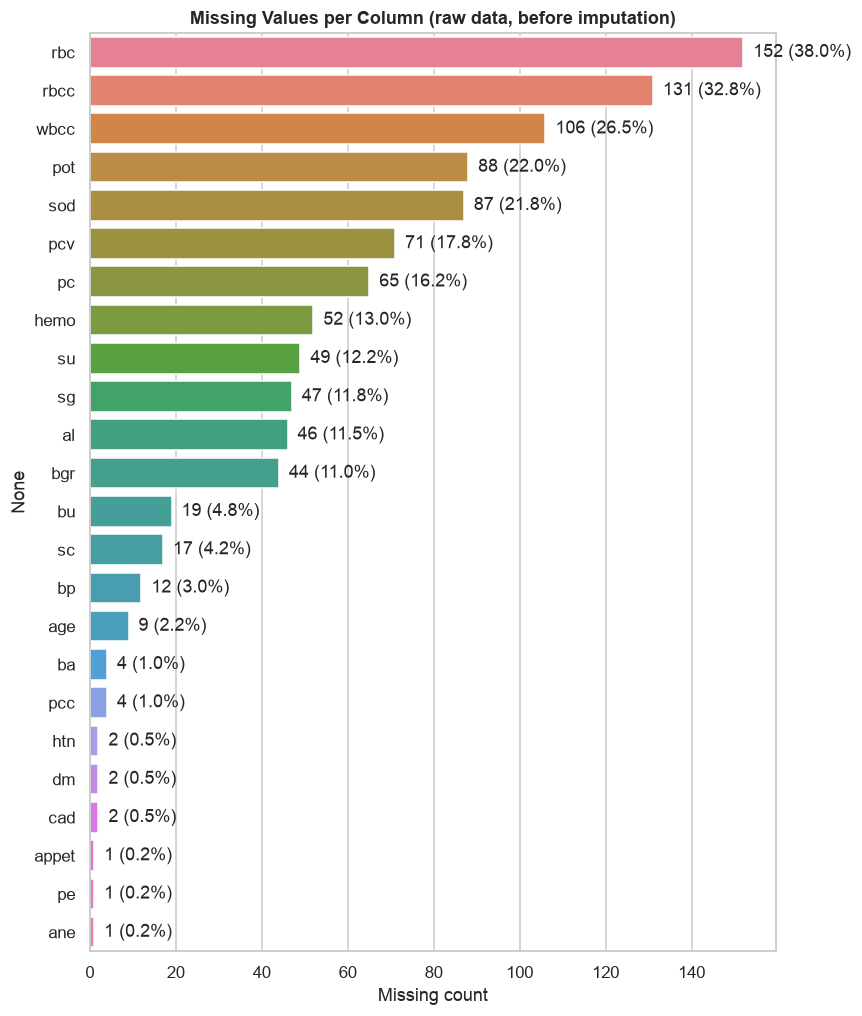

In [4]:
fig = eda.plot_missing_values(df, "ckd")
plt.show()

**Interpretation:** Missingness is substantial and uneven: `rbcc` (red blood
cell count) is missing for 131/400 patients (32.8%), `wbcc` for 106 (26.5%),
`pot`/`sod` for ~88 (22%), and `rbc` (red blood cells, categorical) for 152
(38%) - the single most-missing column in the whole project. These are all
tests that require a full blood panel, plausibly skipped for patients whose
CKD status was already clear from simpler markers. Median/most-frequent
imputation is used here as a practical baseline, but this is the dataset
where imputation choice most plausibly affects results, since almost a third
of some columns are being filled in.


## 3. Disease Prevalence

2026-07-30 15:47:59,366 [INFO] Saved figure to /Users/albertmathew/Desktop/projects/MultiDiseaseAI/reports/figures/ckd_prevalence.png


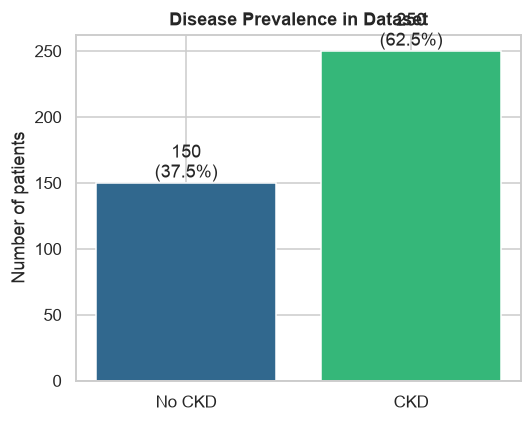

In [5]:
labels = {0: 'No CKD', 1: 'CKD'}
fig = eda.plot_target_prevalence(df, "target", labels, "ckd")
plt.show()

**Interpretation:** 62.5% of patients in this dataset have CKD. This is
*not* representative of general-population CKD prevalence (~10-15%) - this
is a clinically-referred, hospital-collected sample enriched for disease
cases, which is an important caveat for interpreting any absolute risk score
this project produces (discussed further in the main README's Limitations
section).


## 4. Feature Distributions

2026-07-30 15:47:59,890 [INFO] Saved figure to /Users/albertmathew/Desktop/projects/MultiDiseaseAI/reports/figures/ckd_distributions.png


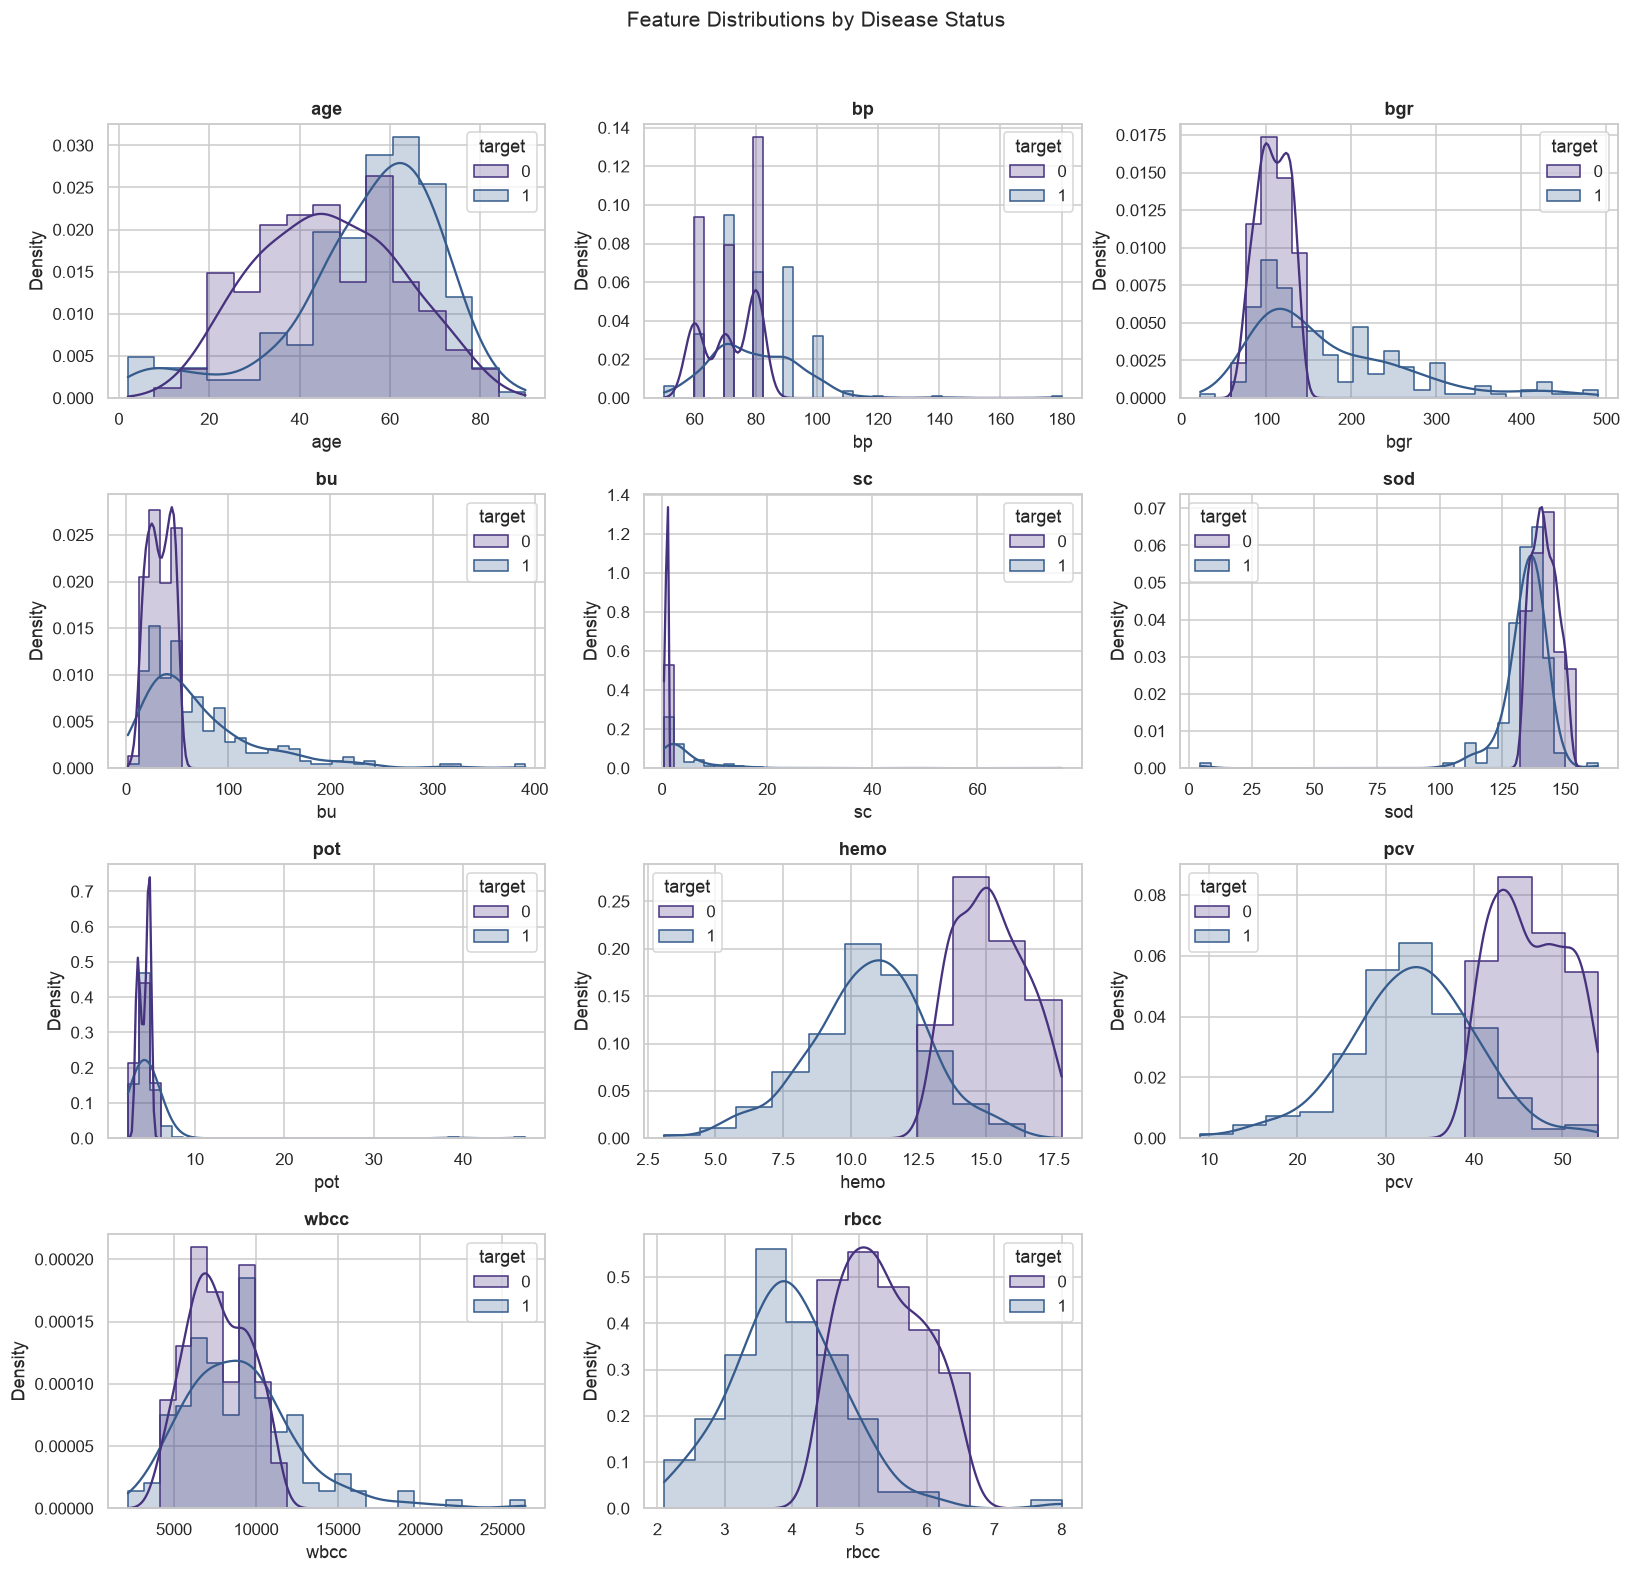

In [6]:
numeric_cols = ['age', 'bp', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']
fig = eda.plot_numeric_distributions(df, numeric_cols, "target", "ckd")
plt.show()

**Interpretation:** `hemo` (hemoglobin) and `pcv` (packed cell volume) are
both clearly shifted lower in the CKD-positive group - anemia is a
well-established consequence of reduced kidney function (reduced
erythropoietin production), so this matches clinical expectations exactly.
`sc` (serum creatinine) is right-skewed with a long tail in the CKD group,
consistent with creatinine rising sharply as kidney filtration deteriorates.


## 5. Boxplots (Outlier Visualization)

2026-07-30 15:48:00,194 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:48:00,196 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:48:00,207 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:48:00,209 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:48:00,218 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


...

2026-07-30 15:48:00,335 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:48:00,337 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:48:00,347 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:48:00,349 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:48:00,583 [INFO] Saved figure to /Users/albertmathew/Desktop/projects/MultiDiseaseAI/reports/figures/ckd_boxplots.png


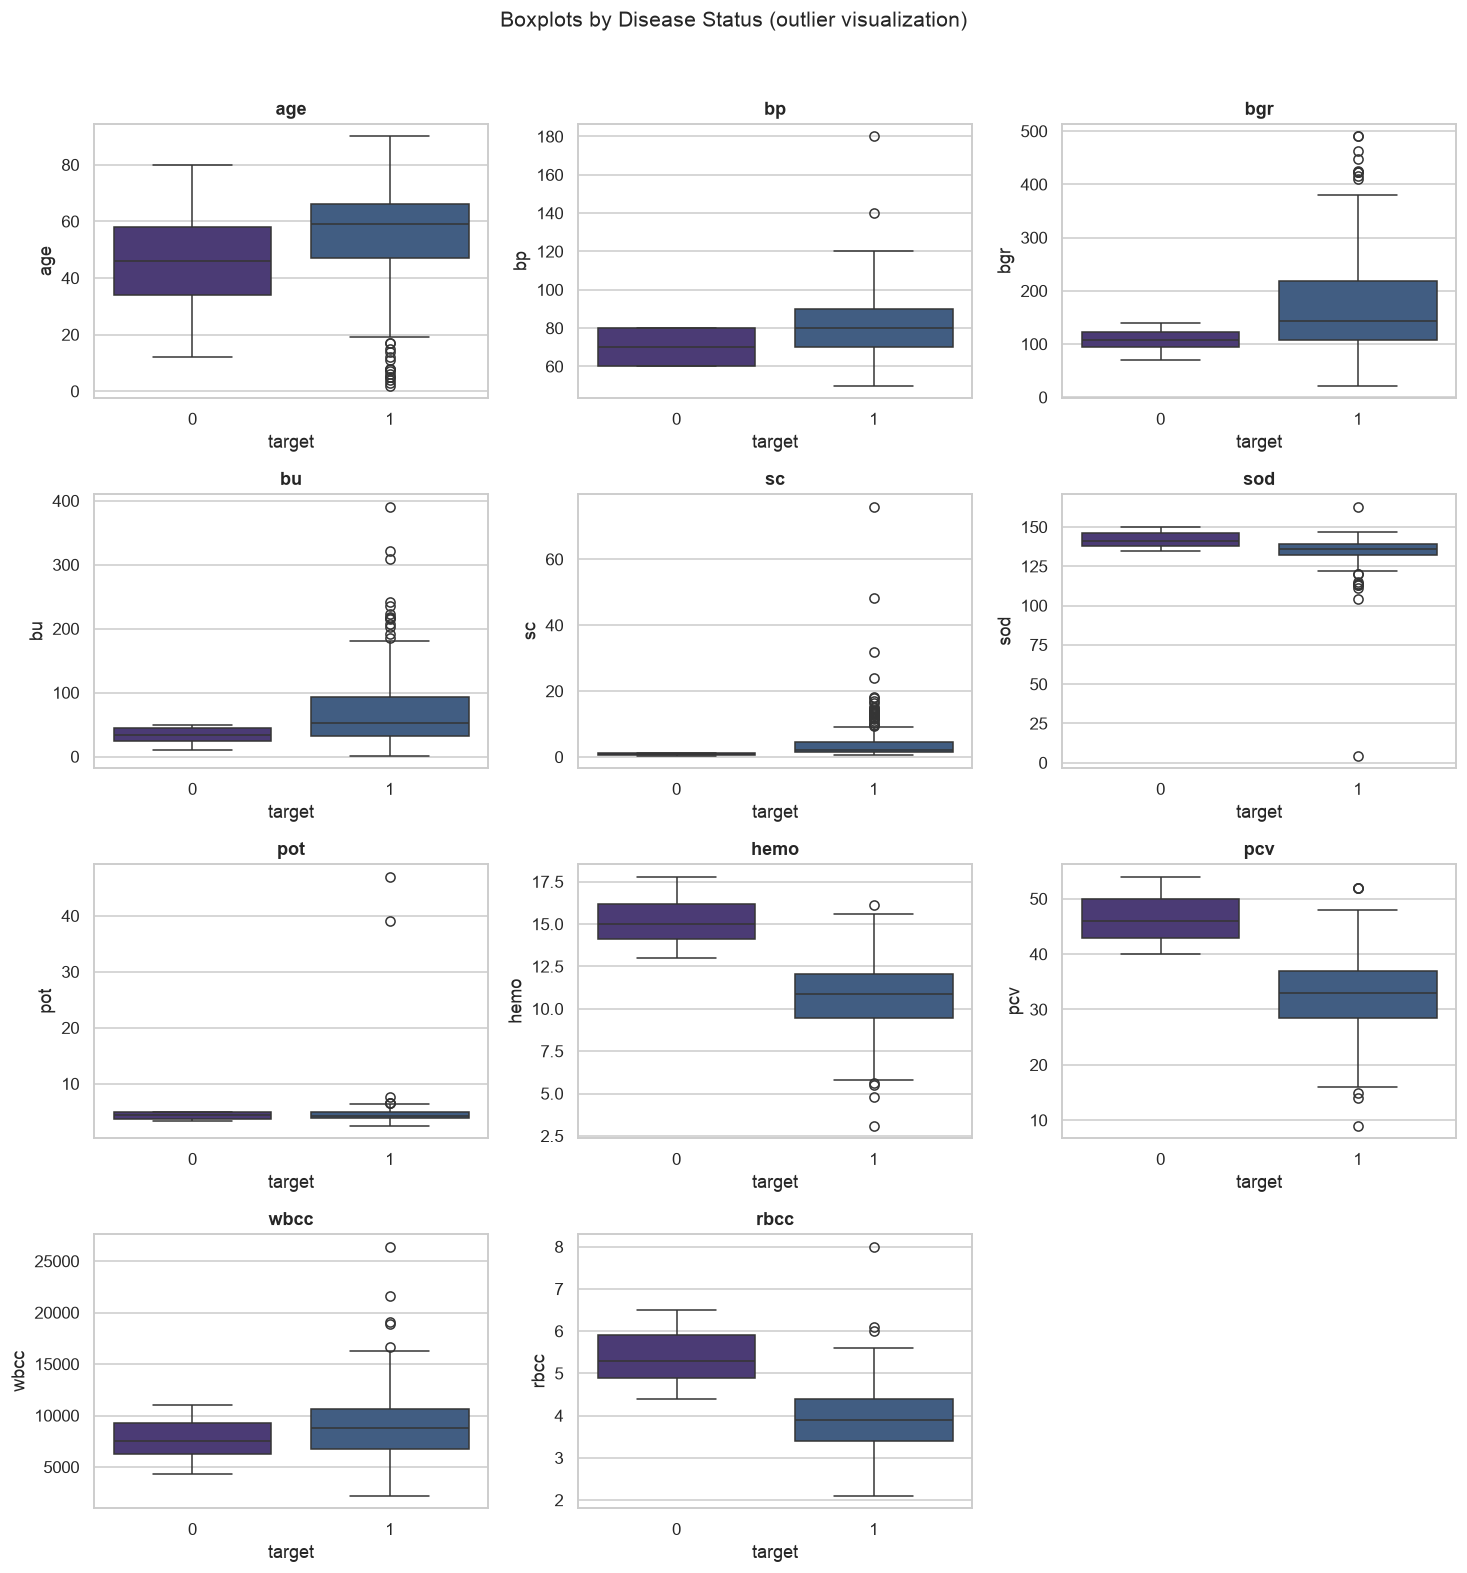

In [7]:
fig = eda.plot_boxplots(df, numeric_cols, "target", "ckd")
plt.show()

**Interpretation:** `hemo`, `pcv`, and `rbcc` all show a strong downward
shift with little overlap between groups - among the cleanest visual
separations in this entire project. `sc` and `bu` (blood urea) show more
outliers in the CKD group extending to very high values, consistent with
advanced-stage patients in a referred clinical sample.


## 6. Correlation Matrix

2026-07-30 15:48:00,935 [INFO] Saved figure to /Users/albertmathew/Desktop/projects/MultiDiseaseAI/reports/figures/ckd_correlation_heatmap.png


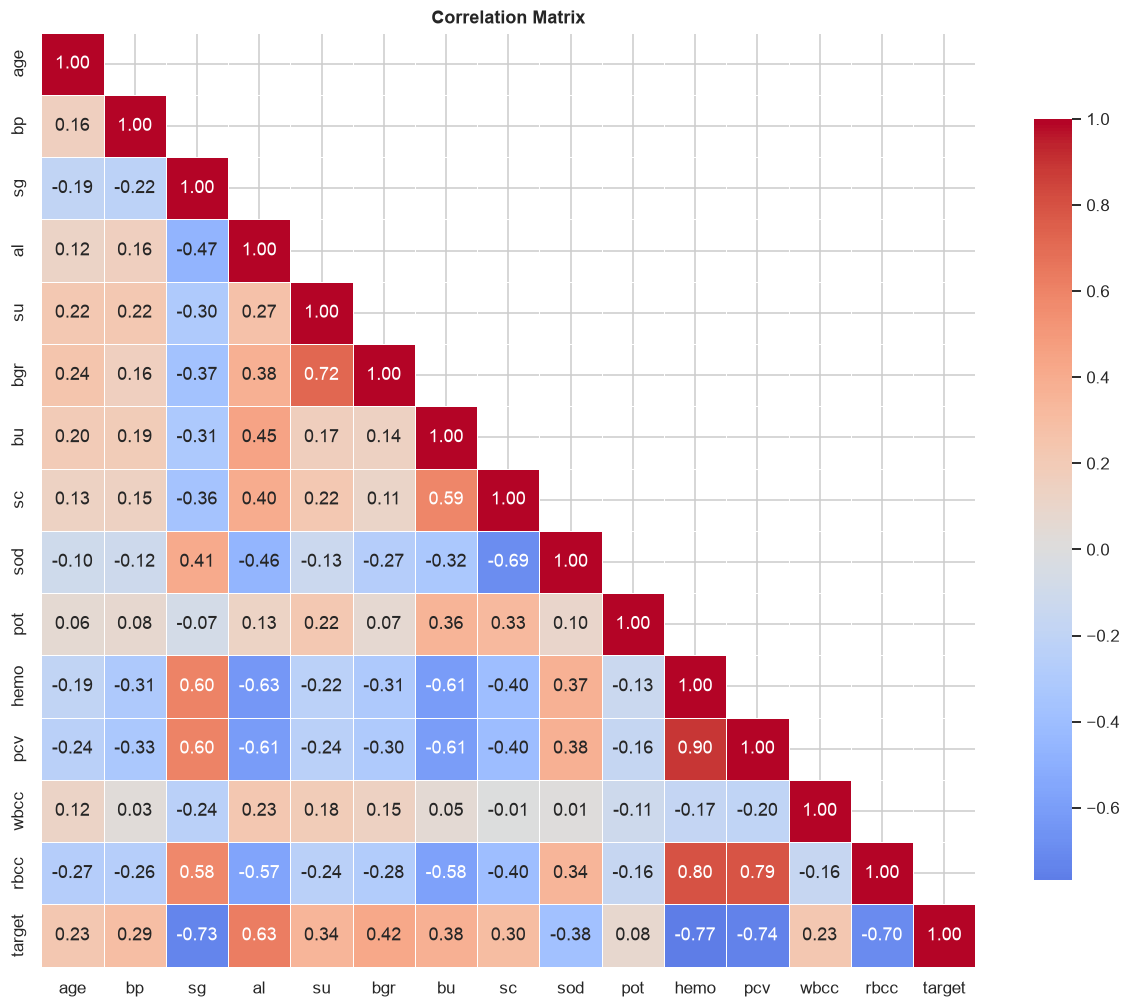

In [8]:
fig = eda.plot_correlation_heatmap(df, "ckd")
plt.show()

In [9]:
eda.target_correlation_ranked(df, "target")

hemo   -0.768919
pcv    -0.741427
sg     -0.732163
rbcc   -0.699089
al      0.627090
bgr     0.419672
bu      0.380605
sod    -0.375674
su      0.344070
sc      0.299969
bp      0.294077
wbcc    0.231919
age     0.227268
pot     0.084541
Name: target, dtype: float64

**Interpretation:** Ranked by |correlation| with `target`: `hemo` (-0.77),
`pcv` (-0.74), `sg` (specific gravity, -0.73), `rbcc` (-0.70), `al` (albumin,
+0.63), `bgr` (+0.42). These correlations are far stronger than in the other
three diseases - CKD's lab markers are direct physiological consequences of
kidney function rather than indirect risk factors, so the linear signal is
much cleaner. `hemo` and `pcv` are also highly correlated *with each other*
(both measure red-cell mass via different methods), which is expected
physiologically and is not a data error.


## 7. Pairplot of Top Correlated Features

2026-07-30 15:48:01,405 [INFO] Saved figure to /Users/albertmathew/Desktop/projects/MultiDiseaseAI/reports/figures/ckd_pairplot.png


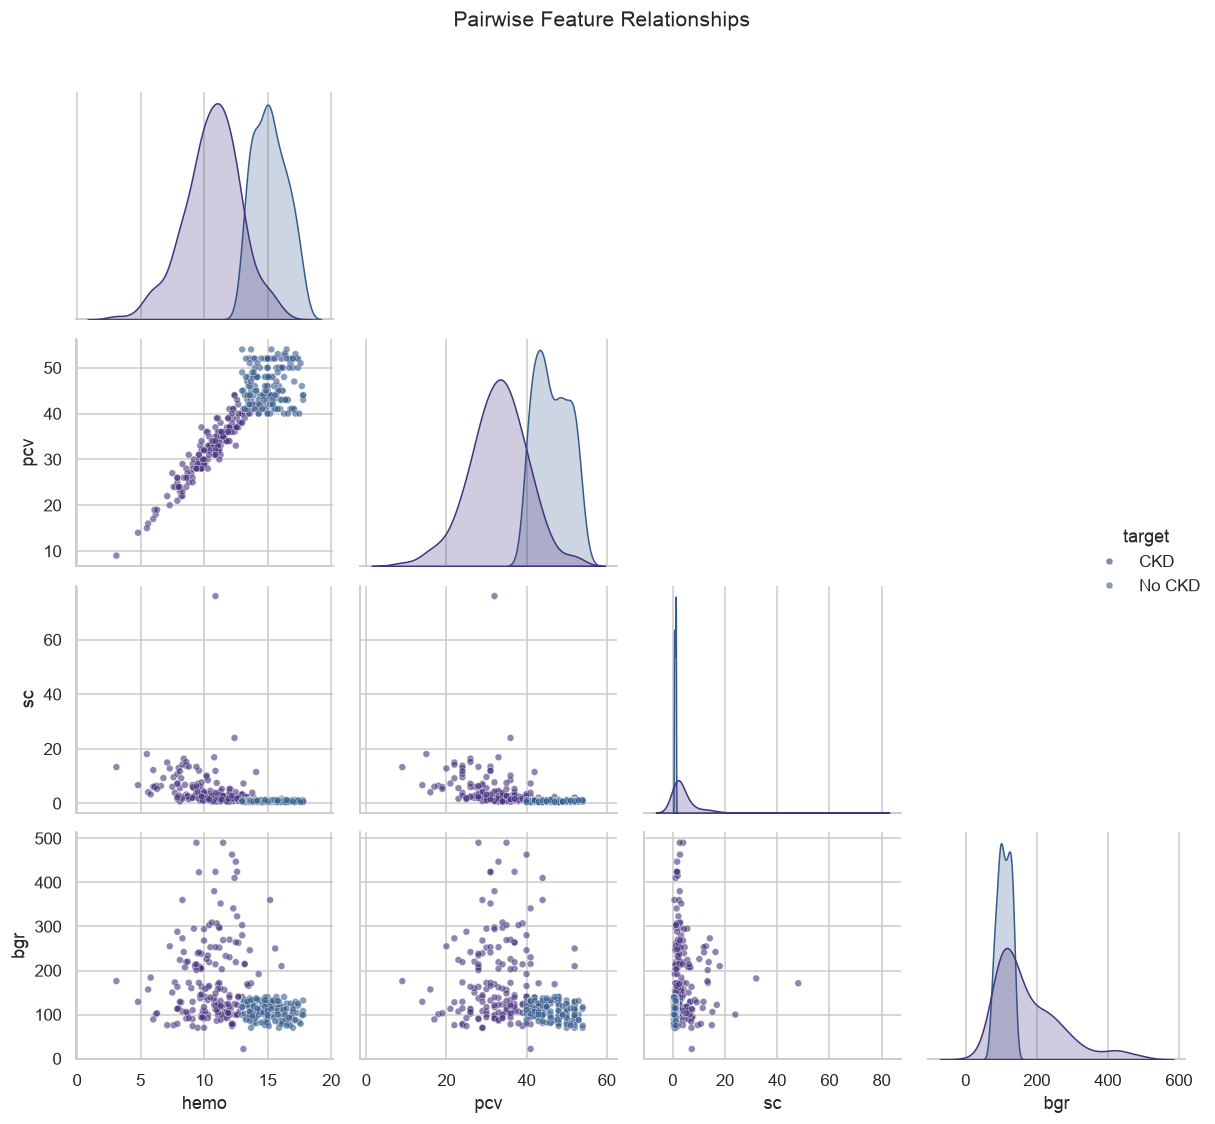

In [10]:
pair_cols = ['hemo', 'pcv', 'sc', 'bgr']
fig = eda.plot_pairplot(df, pair_cols, "target", "ckd", labels)
plt.show()

**Interpretation:** `hemo` vs `pcv` shows an almost linear relationship
between the two (as expected - they measure related quantities), with the
CKD class cleanly separated in the lower-left region of both. `sc` vs `bgr`
shows more overlap, indicating serum creatinine and random blood glucose
provide more complementary than redundant information for this task.


## 8. Summary of Findings

This EDA directly informs the choices made in `src/preprocessing.py` (imputation strategy, outlier clipping) and `src/feature_engineering.py` (which engineered features to add) for this disease. See `src/train.py` for how the cleaned, engineered features feed into the TabPFN model.